Parameters for 1_200G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000: wav_res=0.01715 A, disk_fill_phase_0=0.07355242566510173, res2d=100, res3d=4, mode=faconly, fac_r=[19], fac_long=[45], fac_lat=[0], fac_band=False, fac_band_low=[0], fac_band_high=[0], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=1, a=25.01, T=4.544, phi=0.03
  COG for 'Faculae at blue limb V=4000m/s': 4377.15670 A
Parameters for 1_200G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000: wav_res=0.01715 A, disk_fill_phase_0=0.07303077725612937, res2d=100, res3d=4, mode=faconly, fac_r=[15], fac_long=[0], fac_lat=[0], fac_band=False, fac_band_low=[0], fac_band_high=[0], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=1, a=25.01, T=4.544, phi=0.03
  COG for 'Faculae at center V=4000m/s': 4377.15681 A
Parameters for 1_200G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000: wav_res=0.01715 A, disk_fill_phase_0=0.07355242566510173, res2d=100, res3d=4, mode=faconly, fac_r=[19], fac_long=[-45], fac_lat=[0], fac_band=False, 

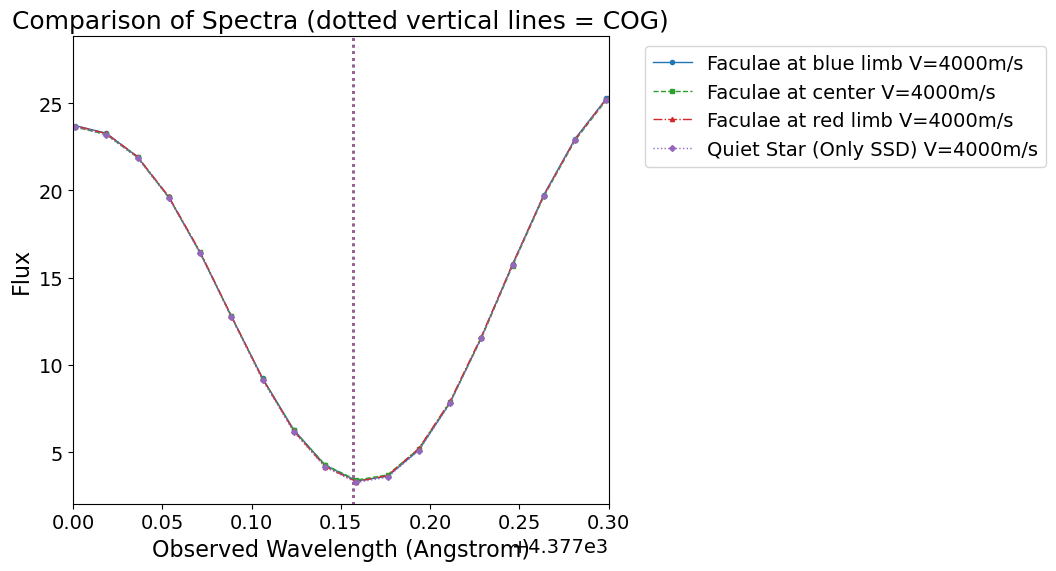

In [14]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from disk_utils import process_disk_directory, get_simulation_params

# Set larger font sizes and thicker lines for overall readability
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'lines.markersize': 8
})

# Set to True to automatically grab all valid subdirectories in the current folder
compare_all_directories = False

if compare_all_directories == True:
    # Grab all subdirectories, ignoring cache, hidden folders, and wdrift folders
    dirs = sorted([
        d for d in glob.glob('./*/') 
        if '__pycache__' not in d 
        and 'wdrift' not in d
        #and '4000' in d
        #and 'div2'  in d
        and 'band' in d
    ])
    directories_to_compare = {d: f"{d.strip('./')} (v={d.split('_v')[-1].strip('/')} m/s)" for d in dirs}
else:
    # Define the directories you want to compare as a dictionary { 'directory_path': 'custom label' }
    directories_to_compare = {
        # './wdrift_4375.6007_4376.3883_fac_lat0_long0_r15/': 'Label 1',
        # './wdrift_4375.6007_4376.3883_fac_lat45_long0_r15/': 'Label 2',
        
     #   './1_4376.5109_4377.4913_fac_lat0_long0_r0_v0/': 'Quiet Star (Only SSD) V=0m/s',
      #  './1_4376.5109_4377.4913_fac_lat0_long0_r0_v2000/': 'Quiet Star (Only SSD) V=2000m/s',
       # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v8000/': 'Quiet Star (Only SSD) V=8000m/s',

        #spots
        # './1_div2fac_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Spot at blue limb V=4000m/s',
        #     './1_div2fac_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Spot at center V=4000m/s',
        # './1_div2fac_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Spot at red limb V=4000m/s',
        # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v4000/': 'Quiet Star (Only SSD) V=4000m/s',

        #faculae
        './1_200G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Faculae at blue limb V=4000m/s',
        './1_200G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae at center V=4000m/s',
        './1_200G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Faculae at red limb V=4000m/s',
        './1_200G_4376.5109_4377.4913_fac_lat0_long0_r0_v4000/': 'Quiet Star (Only SSD) V=4000m/s',

        #bands
        # './1_4376.5109_4377.4913_band_lat-2.5_2.5_v4000/': 'Equatorial band with Faculae V=4000m/s',
        # './1_4376.5109_4377.4913_band_lat45_90_v4000/': 'Polar band with Faculae V=4000m/s',

        #faculae 100G
        # './1_100G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Faculae 100G at blue limb V=4000m/s',
        # './1_100G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 100G at center V=4000m/s',
        # './1_100G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Faculae 100G at red limb V=4000m/s',
        # './1_100G_4376.5109_4377.4913_fac_lat45_long0_r19_v4000/': 'Faculae 100G at bottom limb V=4000m/s',
        # './1_100G_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 100G at top limb V=4000m/s',

        # './1_100G_4376.5109_4377.4913_fac_lat0_long0_r0_v4000/': 'Quiet Star (Only SSD) V=4000m/s',


        # './1_4376.5109_4377.4913_fac_lat0_long45_r19_v0/': 'Star With Facular Spot',
        # './1_div2fac_4376.5109_4377.4913_fac_lat0_long45_r19_v0/': 'Star With Dark Spot',



    


        
        # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v4000/': 'Custom Label 3',
        # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v8000/': 'Custom Label 4',
    }

# Distinct (color, marker) per series so a curve stays identifiable. Colours
# chosen so the series match their physical meaning: blue limb -> blue,
# centre -> green, red limb -> red.
style_cycle = [
    {'color': '#1f77b4', 'linestyle': '-',  'marker': 'o'},   # blue limb
    {'color': '#2ca02c', 'linestyle': '--', 'marker': 's'},   # centre  -> green
    {'color': '#d62728', 'linestyle': '-.', 'marker': '^'},   # red limb -> red
    {'color': '#9467bd', 'linestyle': ':',  'marker': 'D'},   # quiet star
    {'color': '#ff7f0e', 'linestyle': '-',  'marker': 'v'},
    {'color': '#8c564b', 'linestyle': '--', 'marker': 'P'},
    {'color': '#17becf', 'linestyle': '-.', 'marker': 'X'},
    {'color': '#e377c2', 'linestyle': ':',  'marker': '*'},
]

x_lo, x_hi = 4377.0, 4377.3


def line_cog(wl, flux, lo, hi):
    """Flux-weighted centre of gravity of the absorption line within [lo, hi].

    Follows the COG definition in Kroll et al. (2026), Appendix D.1: the
    centroid is weighted by the absorption depth a(lambda) = 1 - f(lambda),
    with f the continuum-normalised profile. Our spectra are raw flux, so we
    use a(lambda) = continuum - flux with the continuum estimated as the max
    flux inside the window; the centroid is invariant to that overall scaling.
    """
    wl = np.asarray(wl)
    flux = np.asarray(flux)
    m = (wl >= lo) & (wl <= hi)
    wlw, fw = wl[m], flux[m]
    depth = np.clip(fw.max() - fw, 0, None)   # absorption depth >= 0
    if depth.sum() == 0:
        return np.nan
    return np.sum(wlw * depth) / np.sum(depth)


fig, ax = plt.subplots(figsize=(11, 6), dpi=100)

cog_results = []   # (label, cog_wavelength) for the ordering printout

for i, (directory, custom_label) in enumerate(directories_to_compare.items()):
    try:
        # Retrieve the binned spectrum data
        bin_centers, binned_intensity = process_disk_directory(directory, phase_idx=0)

        # Try to read parameters for the legend
        params = get_simulation_params(directory)

        # Calculate wav_res: total angstroms / wavelength bins
        wav_res = (bin_centers[-1] - bin_centers[0]) / len(bin_centers)
        params = f"wav_res={wav_res:.5f} A, {params}"

        print(f"Parameters for {directory.strip('./')}: {params}")

        style = style_cycle[i % len(style_cycle)]

        # The spectrum itself.
        ax.plot(bin_centers, binned_intensity, markersize=3, linewidth=1,
                alpha=1.0, label=custom_label, **style)

        # Vertical COG line for this curve (matching colour, dotted).
        cog = line_cog(bin_centers, binned_intensity, x_lo, x_hi)
        if np.isfinite(cog):
            ax.axvline(cog, color=style['color'], linestyle=':', linewidth=1.8,
                       alpha=0.9)
            print(f"  COG for '{custom_label}': {cog:.5f} A")
            cog_results.append((custom_label, cog))

    except Exception as e:
        print(f"Error processing {directory}: {e}")

# Wavelength ordering of the COG lines (bluest -> reddest, i.e. left -> right).
if cog_results:
    print("\nCOG wavelength ordering (bluest -> reddest):")
    for rank, (lab, cog) in enumerate(sorted(cog_results, key=lambda t: t[1]), start=1):
        print(f"  {rank}. {lab}: {cog:.5f} A")

ax.set_xlabel('Observed Wavelength (Angstrom)')
ax.set_ylabel('Flux')
ax.set_title('Comparison of Spectra (dotted vertical lines = COG)')
ax.set_xlim(x_lo, x_hi)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

fig.tight_layout()
fig.savefig('comparison_phase0_binned_spectra.png', dpi=300, bbox_inches='tight')
plt.show()

/rds/general/user/dsy24/ephemeral/ipykernel_2722236/1234697048.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


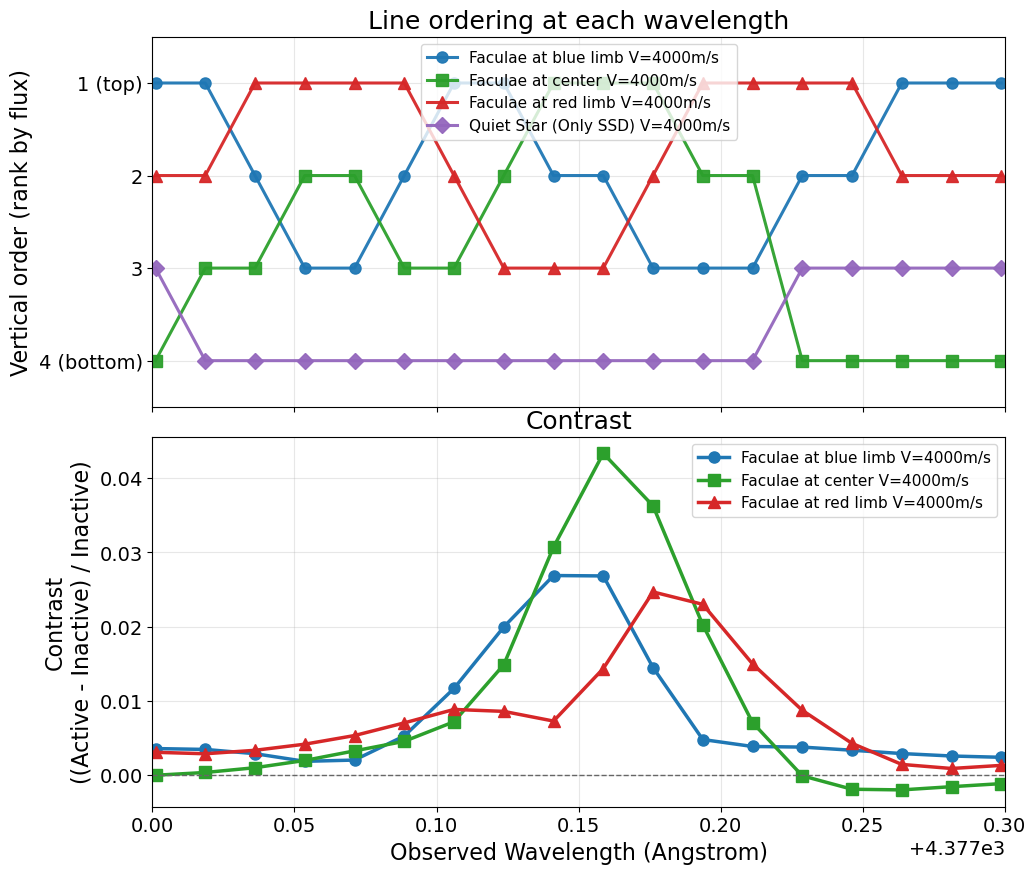

In [17]:
import re
import numpy as np
import matplotlib.pyplot as plt
from disk_utils import process_disk_directory

# Stack two vertically-aligned panels that share the wavelength axis:
#   top    -> line ordering (rank by flux) at each wavelength  [bump chart]
#   bottom -> contrast (active - inactive) / inactive, exactly as the cell below
# Reuses `directories_to_compare` and `style_cycle` defined in the cell above.

x_lo, x_hi = 4377., 4377.3

fig, (ax_rank, ax_con) = plt.subplots(
    2, 1, figsize=(11, 10), dpi=100, sharex=True,
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.08})

labels, styles = [], []
common_x, intensity_stack = None, []

for i, (directory, custom_label) in enumerate(directories_to_compare.items()):
    try:
        bin_centers, binned_intensity = process_disk_directory(directory, phase_idx=0)
        bc = np.asarray(bin_centers)
        by = np.asarray(binned_intensity)
        if common_x is None:
            common_x = bc
        intensity_stack.append(np.interp(common_x, bc, by))
        labels.append(custom_label)
        styles.append(style_cycle[i % len(style_cycle)])
    except Exception as e:
        print(f"Error processing {directory}: {e}")

# ---- Top panel: line ordering (rank by flux) --------------------------------
if intensity_stack:
    I = np.vstack(intensity_stack)                 # (n_series, n_wl)
    order = np.argsort(-I, axis=0)                 # rank 1 = brightest
    ranks = np.empty_like(I, dtype=int)
    for r in range(order.shape[0]):
        ranks[order[r], np.arange(I.shape[1])] = r + 1

    mask = (common_x >= x_lo) & (common_x <= x_hi)
    xr = common_x[mask]
    for k, (lab, style) in enumerate(zip(labels, styles)):
        ax_rank.plot(xr, ranks[k][mask], markersize=8, linewidth=2.2, alpha=0.95,
                     label=lab, **{**style, 'linestyle': '-'})

    n = len(labels)
    ax_rank.set_yticks(range(1, n + 1))
    ax_rank.set_yticklabels([f'{r} (top)' if r == 1 else
                             f'{r} (bottom)' if r == n else str(r)
                             for r in range(1, n + 1)])
    ax_rank.set_ylim(n + 0.5, 0.5)                  # rank 1 at the top
    ax_rank.set_ylabel('Vertical order (rank by flux)')
    ax_rank.set_title('Line ordering at each wavelength')
    ax_rank.grid(True, alpha=0.3)
    ax_rank.legend(loc='upper center', fontsize=11)

# ---- Bottom panel: contrast (active - inactive) / inactive ------------------
# Same construction as the cell below: build each inactive counterpart by
# zeroing lat / long / r (and collapsing any band spec to fac_lat0_long0_r0).
for i, (active, custom_label) in enumerate(directories_to_compare.items()):
    inactive = re.sub(r'band_lat-?[\d\.]+_-?[\d\.]+', 'fac_lat0_long0_r0', active)
    inactive = re.sub(r'lat-?\d+', 'lat0', inactive)
    inactive = re.sub(r'long-?\d+', 'long0', inactive)
    inactive = re.sub(r'r\d+', 'r0', inactive)

    if active == inactive:
        continue  # e.g. the quiet-star reference has no active counterpart

    try:
        _, ia = process_disk_directory(active, phase_idx=0)
        bc_in, ii = process_disk_directory(inactive, phase_idx=0)
        contrast = (np.asarray(ia) - np.asarray(ii)) / np.asarray(ii)

        v_match = re.search(r'_v(\d+)', active)
        velocity = v_match.group(1) if v_match else "unknown"
        style = style_cycle[i % len(style_cycle)]
        ax_con.plot(bc_in, contrast, linewidth=2.5, alpha=1.0,
                    label=f'{custom_label}', **{**style, 'linestyle': '-'})
    except Exception as e:
        print(f"Error processing contrast for {active} vs {inactive}: {e}")

ax_con.axhline(0, color='0.4', linestyle='--', linewidth=1)
ax_con.set_xlim(x_lo, x_hi)
ax_con.set_xlabel('Observed Wavelength (Angstrom)')
ax_con.set_ylabel('Contrast\n((Active - Inactive) / Inactive)')
ax_con.set_title('Contrast')
ax_con.grid(True, alpha=0.3)
ax_con.legend(loc='best', fontsize=11)

fig.tight_layout()
fig.savefig('ordering_and_contrast_phase0.png', dpi=300, bbox_inches='tight')
plt.show()

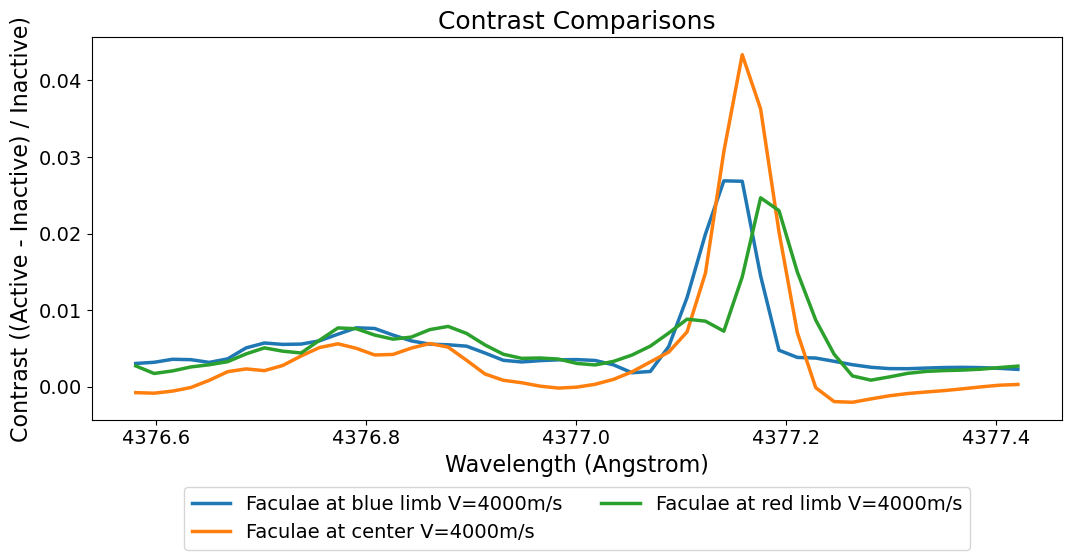

In [8]:
import os
import glob
import re
import matplotlib.pyplot as plt
from disk_utils import process_disk_directory, get_simulation_params

# Choose whether to explicitly define directories or search for them
use_explicit_dirs = True

# --- Option 1: Explicitly define active directories and custom labels ---
explicit_active_dirs = {
    #spots
    # './1_div2fac_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Spot at blue limb',
    # './1_div2fac_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Spot at center',
    # './1_div2fac_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Spot at red limb',

    #faculae
    './1_200G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Faculae at blue limb',
    './1_200G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae at center',
    './1_200G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Faculae at red limb',

    #bands
    # './1_4376.5109_4377.4913_band_lat-2.5_2.5_v4000/': 'Equatorial band with Faculae',
    # './1_4376.5109_4377.4913_band_lat45_90_v4000/': 'Polar band with Faculae',

    #faculae 100G
#     './1_100G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Faculae 100G at blue limb',
    # './1_100G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 100G at center',
#     './1_100G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Faculae 100G at red limb',
#    # './1_100G_4376.5109_4377.4913_fac_lat45_long0_r19_v4000/': 'Faculae 100G at bottom limb s',
     #'./1_100G_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 100G at top limb',

    #activity comparison top limb
    # './1_100G_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 100G at top limb',
    # './1_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 200G at top limb',
    # './1_300G_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 300G at top limb',

    #activity comparison disk center
    # './1_100G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 100G at disk center',
    # './1_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 200G at disk center',
    # './1_300G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 300G at disk center',

    #no rotation vs rotation facular band
    #  './1_4376.5109_4377.4913_band_lat-2.5_2.5_v4000/': 'Band at center',
    #  './1_4376.5109_4377.4913_band_lat-2.5_2.5_v0/': 'Band at center',

}

# --- Option 2: Define strings that MUST be present in the directory name ---
search_strings = []

if use_explicit_dirs:
    active_dirs_dict = explicit_active_dirs
else:
    found_dirs = sorted([
        d for d in glob.glob('./*/') 
        if '__pycache__' not in d 
        and 'wdrift' not in d
        and all(s in d for s in search_strings)
    ])
    active_dirs_dict = {d: extract_features(d) for d in found_dirs}

# Automatically generate inactive counterpart by zeroing lat, long, and r
comparisons = []
for active, custom_label in active_dirs_dict.items():
    # Properly substitute band format (including possible decimals) to fac format for quiet star
    inactive = re.sub(r'band_lat-?[\d\.]+_-?[\d\.]+', 'fac_lat0_long0_r0', active)
    inactive = re.sub(r'lat-?\d+', 'lat0', inactive)
    inactive = re.sub(r'long-?\d+', 'long0', inactive)
    inactive = re.sub(r'r\d+', 'r0', inactive)
    
    # Don't compare the inactive line against itself
    if active != inactive:
        comparisons.append((active, inactive, custom_label))

def extract_features(dir_path):
    folder = dir_path.strip('./')
    idx = folder.find('_fac_')
    if idx != -1:
    # Add 1 to index to drop the leading underscore, or simply do .lstrip('_')
        return folder[idx + 1:] 
    return folder[idx:] if idx != -1 else folder

if comparisons:
    plt.figure(figsize=(11, 6), dpi=100)
    
    for dir_active, dir_inactive, custom_label in comparisons:
        try:
            # Retrieve the binned spectrum data again for the two disks
            bin_centers_active, binned_intensity_active = process_disk_directory(dir_active, phase_idx=0)
            bin_centers_inactive, binned_intensity_inactive = process_disk_directory(dir_inactive, phase_idx=0)

            # Calculate contrast: (active - inactive) / inactive
            # Assuming both arrays share the exact same bin centers
            contrast = (binned_intensity_active - binned_intensity_inactive) / binned_intensity_inactive

            v_match = re.search(r'_v(\d+)', dir_active)
            velocity = v_match.group(1) if v_match else "unknown"

            label_active = extract_features(dir_active)
            label_inactive = extract_features(dir_inactive)

            plt.plot(bin_centers_active, contrast, linestyle='-', linewidth=2.5, alpha = 1.0,
                     label=f'{custom_label} V={velocity}m/s')
                     
        except Exception as e:
            print(f"Error processing contrast for {dir_active} vs {dir_inactive}: {e}")

    # # Add a horizontal line at 0 for reference
    # plt.axhline(0, color='black', linestyle='--', linewidth=1)

    plt.xlabel('Wavelength (Angstrom)')
    plt.ylabel('Contrast ((Active - Inactive) / Inactive)')
    plt.title('Contrast Comparisons')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print("Please provide at least one active directory to calculate contrast.")

Simulation Parameters:
# disk_fill_phase_0=0.0, res2d=100, res3d=4, mode=faconly, fac_r=[0], fac_long=[0], fac_lat=[0], fac_band=False, fac_band_low=[0], fac_band_high=[0], ld=power2, v_eq=0, inc=90, rp=0.1808, b=-0.04, N=1, a=25.01, T=4.544, phi=0.03 



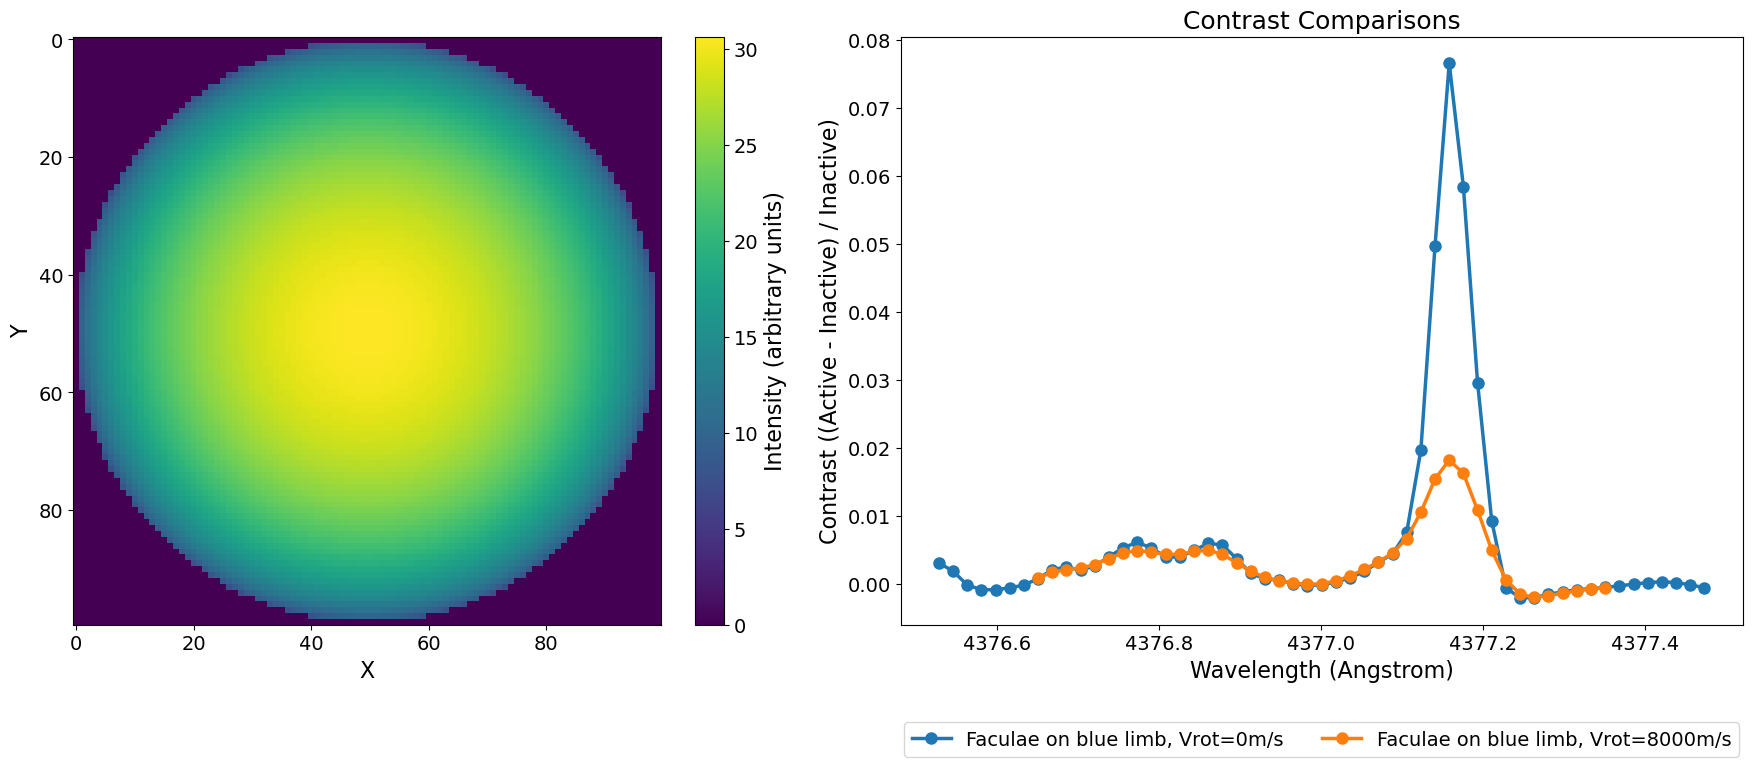

In [3]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from disk_utils import process_disk_directory, get_simulation_params

# Set larger font sizes for LaTeX readability
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'lines.markersize': 8
})

# =========================================================
# Part 1: Intensity Map Setup
# =========================================================
directory = './1_4376.5109_4377.4913_fac_lat0_long0_r0_v0/'

# Print simulation parameters from first csv
first_csv = next(Path('.').glob(f'{directory}/wavelength_shifts_inp*.csv'), None)
if first_csv:
    with open(first_csv, 'r') as f:
        header = f.readline()
        print("Simulation Parameters:")
        print(header.strip(), '\n')
else:
    print("No .csv files found to read the header from.")

# Load intensity maps
npy_files = sorted(Path('.').glob(f'{directory}/disk_inp*.npy'))
if not npy_files:
    raise FileNotFoundError("No files found matching pattern: disk_inp*.npy")

def parse_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.npy$', p.name)
    return float(m.group(1)) if m else np.nan

intensity_maps = {}
for f in npy_files:
    wl = parse_wavelength(f)
    intensity_maps[wl] = np.load(f)

# =========================================================
# Part 2: Contrast Setup
# =========================================================
use_explicit_dirs = True
explicit_active_dirs = [
    './1_4376.5109_4377.4913_fac_lat0_long0_r15_v0/',
    './1_4376.5109_4377.4913_fac_lat0_long0_r15_v8000/',


    # './1_4376.5109_4377.4913_fac_lat0_long45_r15_v2000/',
    # './1_4376.5109_4377.4913_fac_lat0_long45_r15_v4000/',
    # './1_4376.5109_4377.4913_fac_lat0_long45_r15_v8000/',
]

if use_explicit_dirs:
    active_dirs = explicit_active_dirs
else:
    search_strings = ['facline_removed']
    active_dirs = sorted([
        d for d in glob.glob('./*/') 
        if '__pycache__' not in d 
        and 'wdrift' not in d
        and all(s in d for s in search_strings)
    ])

comparisons = []
for active in active_dirs:
    inactive = re.sub(r'lat-?\d+', 'lat0', active)
    inactive = re.sub(r'long-?\d+', 'long0', inactive)
    inactive = re.sub(r'r\d+', 'r0', inactive)
    
    if active != inactive:
        comparisons.append((active, inactive))

def extract_features(dir_path):
    folder = dir_path.strip('./')
    idx = folder.find('_fac_')
    if idx != -1:
        return folder[idx + 1:] 
    return folder[idx:]

# =========================================================
# Part 3: Create Subplots
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), dpi=100)

# --- Left subplot: Intensity map ---
plot_wl = sorted(intensity_maps.keys())[0]
idx = 0
img_data = intensity_maps[plot_wl][idx]

im = ax1.imshow(img_data, cmap='viridis')
#ax1.set_title(f'Intensity Map (Wavelength {plot_wl} | Phase {idx})')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('Intensity (arbitrary units)')

# --- Right subplot: Contrast comparisons ---
if comparisons:
    for dir_active, dir_inactive in comparisons:
        try:
            bin_centers_active, binned_intensity_active = process_disk_directory(dir_active, phase_idx=0)
            bin_centers_inactive, binned_intensity_inactive = process_disk_directory(dir_inactive, phase_idx=0)

            contrast = (binned_intensity_active - binned_intensity_inactive) / binned_intensity_inactive

            v_match = re.search(r'_v(\d+)', dir_active)
            velocity = v_match.group(1) if v_match else "unknown"

            ax2.plot(bin_centers_active, contrast, linestyle='-', linewidth=2.5, alpha=1.0,
                     marker='o', markersize=8,
                     label=f'Faculae on blue limb, Vrot={velocity}m/s')
                     
        except Exception as e:
            print(f"Error processing contrast for {dir_active} vs {dir_inactive}: {e}")

    ax2.set_xlabel('Wavelength (Angstrom)')
    ax2.set_ylabel('Contrast ((Active - Inactive) / Inactive)')
    ax2.set_title('Contrast Comparisons')
    # Place legend below the plot to keep the area clear
    ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
else:
    print("Please provide at least one active directory to calculate contrast.")

# Adjust layout and save high-res png
plt.tight_layout()
plt.savefig('combined_intensity_contrast_faculae.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
#lots of things going on here. At line cores, can we see further into the disk or shallower?
#when faculae are at the limbs, we see the hot walls so it will be brighter, but only inside absorption lines?
#shouldn't the faculae contrast be brighter then at the limb
#seems like the faculae are brighter except inside line cores, where they're a little bit darker, I guess because those form deeper into the atmosphere where the contributions are more similar? Check back on this logic

#the faculae are brighter in the continuum at the limb, dimmer in the line cores at the limb

Error processing contrast for ./4376.5109_4377.4913_fac_lat0_long45_r19_v4000/ vs ./4376.5109_4377.4913_fac_lat0_long0_r0_v4000/: No disk_inp*.npy files found in 4376.5109_4377.4913_fac_lat0_long45_r19_v4000
Error processing contrast for ./4376.5109_4377.4913_fac_lat0_long45_r19_v2000/ vs ./4376.5109_4377.4913_fac_lat0_long0_r0_v2000/: No disk_inp*.npy files found in 4376.5109_4377.4913_fac_lat0_long45_r19_v2000
Error processing contrast for ./4376.5109_4377.4913_fac_lat0_long45_r19_v8000/ vs ./4376.5109_4377.4913_fac_lat0_long0_r0_v8000/: No disk_inp*.npy files found in 4376.5109_4377.4913_fac_lat0_long45_r19_v8000


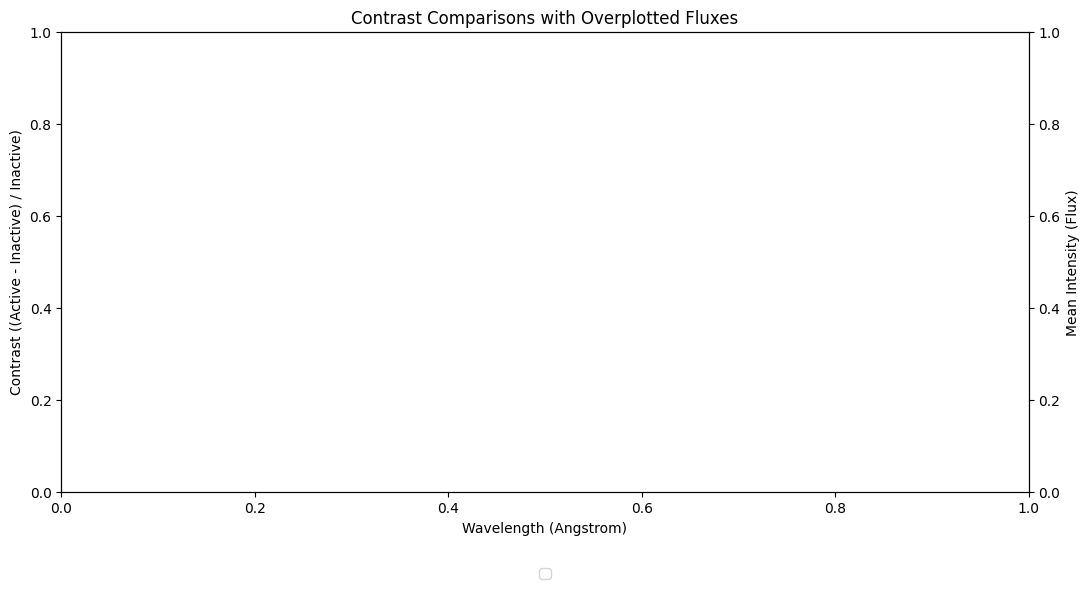

In [1]:
import os
import glob
import re
import matplotlib.pyplot as plt
from disk_utils import process_disk_directory, get_simulation_params

# Choose whether to explicitly define directories or search for them
use_explicit_dirs = True

# --- Option 1: Explicitly define active directories ---
explicit_active_dirs = [
    # './4376.5109_4377.4913_fac_lat0_long0_r15_v4000/',
    './4376.5109_4377.4913_fac_lat0_long45_r19_v4000/',
    './4376.5109_4377.4913_fac_lat0_long45_r19_v2000/',
    './4376.5109_4377.4913_fac_lat0_long45_r19_v8000/',


    # './4376.5109_4377.4913_fac_lat0_long61_r23_v4000/',

    # './4376.5109_4377.4913_fac_lat0_long0_r15_v4000_facline_removed/',
    # './4376.5109_4377.4913_fac_lat0_long45_r19_v4000_facline_removed/',

]

# --- Option 2: Define strings that MUST be present in the directory name ---
search_strings = ['facline_removed']

if use_explicit_dirs:
    active_dirs = explicit_active_dirs
else:
    active_dirs = sorted([
        d for d in glob.glob('./*/') 
        if '__pycache__' not in d 
        and 'wdrift' not in d
        and all(s in d for s in search_strings)
    ])

# Automatically generate inactive counterpart by zeroing lat, long, and r
comparisons = []
for active in active_dirs:
    inactive = re.sub(r'lat-?\d+', 'lat0', active)
    inactive = re.sub(r'long-?\d+', 'long0', inactive)
    inactive = re.sub(r'r\d+', 'r0', inactive)
    
    # Don't compare the inactive line against itself
    if active != inactive:
        comparisons.append((active, inactive))

def extract_features(dir_path):
    folder = dir_path.strip('./')
    idx = folder.find('fac_')
    return folder[idx:] if idx != -1 else folder

if comparisons:
    fig, ax1 = plt.subplots(figsize=(11, 6), dpi=100)
    ax2 = ax1.twinx()  # Create a secondary y-axis for the fluxes
    
    plotted_baselines = set()
    
    for dir_active, dir_inactive in comparisons:
        try:
            # Retrieve the binned spectrum data again for the two disks
            bin_centers_active, binned_intensity_active = process_disk_directory(dir_active, phase_idx=0)
            bin_centers_inactive, binned_intensity_inactive = process_disk_directory(dir_inactive, phase_idx=0)

            # Calculate contrast: (active - inactive) / inactive
            # Assuming both arrays share the exact same bin centers
            contrast = (binned_intensity_active - binned_intensity_inactive) / binned_intensity_inactive

            v_match = re.search(r'_v(\d+)', dir_active)
            velocity = v_match.group(1) if v_match else "unknown"
            active_label_str = f'spot on blue limb Vrot {velocity}m/s'
            label_inactive = extract_features(dir_inactive)

            # Plot contrast on primary axis (ax1)
            line = ax1.plot(bin_centers_active, contrast, linestyle='-', linewidth=2.5, alpha=1.0,
                            label=active_label_str)[0]
            color = line.get_color()
            
            # Plot the active flux on secondary axis (ax2)
            ax2.plot(bin_centers_active, binned_intensity_active, linestyle=':', linewidth=2.5, alpha=1.0, color=color,
                     label=f'Flux: {active_label_str}')
                     
            # Plot the inactive baseline flux just once per unique baseline
            if label_inactive not in plotted_baselines:
                ax2.plot(bin_centers_inactive, binned_intensity_inactive, linestyle='--', linewidth=2.5, alpha=1.0, color='black',
                         label=f'Baseline Flux: {label_inactive}')
                plotted_baselines.add(label_inactive)
                     
        except Exception as e:
            print(f"Error processing contrast for {dir_active} vs {dir_inactive}: {e}")

    # plt.axhline(0, color='black', linestyle='--', linewidth=1)

    ax1.set_xlabel('Wavelength (Angstrom)')
    ax1.set_ylabel('Contrast ((Active - Inactive) / Inactive)')
    ax2.set_ylabel('Mean Intensity (Flux)')
    
    plt.title('Contrast Comparisons with Overplotted Fluxes')
    
    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    
    plt.tight_layout()
    plt.show()
else:
    print("Please provide at least one active directory to calculate contrast.")